In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as Widget
from IPython.display import display

df = pd.read_csv("netflix_titles.csv")
df.dropna(subset=["country", "release_year", "type"], inplace=True)


In [2]:
type_filter=Widget.Dropdown(
    options=['All']+ sorted(df['type'].unique()),
    value='All',
    description='Content Type:'
)


df['country'] = df['country'].astype(str).str.strip()
df = df[df['country'].str.lower() != 'nan']

country_series = df['country'].apply(lambda x: [i.strip() for i in x.split(',')])
all_countries = sorted(set(country for sublist in country_series for country in sublist))




country_filter=Widget.Dropdown(
    options=['All']+ all_countries,
    value='All',
    description='Country',
    layout=Widget.Layout(width='50%')
)
year_slider=Widget.IntSlider(
    value=2015,
    min=df['release_year'].min(),
    max=df['release_year'].max(),
    step=1,
    description='Year>=',
    continuous_update=False,
    layout=Widget.Layout(width='70%')
)


In [3]:
def filter_and_plot(content_type, country, min_year):
    filtered = df[df['release_year'] >= min_year]
    
    if content_type != 'All':
        filtered = filtered[filtered['type'] == content_type]
    
    if country != 'All':
        # Use str.contains instead of == for comma-separated values
        filtered = filtered[filtered['country'].str.contains(country, case=False, na=False)]
    
    if filtered.empty:
        print("No data matches the selected filters.")
        return
    
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=filtered,
        x='release_year',
        order=sorted(filtered['release_year'].unique()),
        palette='mako'
    )
    plt.title('Releases Over Time')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18088\3958198321.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


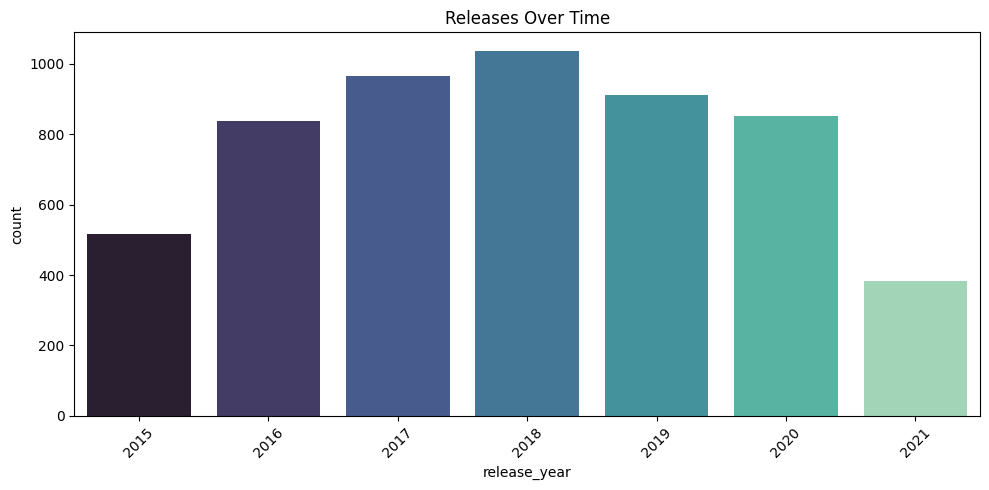

In [4]:
def on_filter_change(change=None):
    clear_output(wait=True)
    display(ui)
    filter_and_plot(
        type_filter.value,
        country_filter.value,
        year_slider.value
    )

# Attach observers
type_filter.observe(on_filter_change, names='value')
country_filter.observe(on_filter_change, names='value')
year_slider.observe(on_filter_change, names='value')

# Layout and display
ui = Widget.VBox([type_filter, country_filter, year_slider])
display(ui)
filter_and_plot('All', 'All', 2015)



voila netflix_dashboard.ipynb
